# EDA y Limpieza: Banco 1 (BO VIP)

**Dataset:** `Copia de 01_bo_vip_seed22_n100000.csv`  
**Output:** `bo_vip_clean.csv` en `proyecto_plus_ti/datasets/`

In [1]:
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from IPython.display import display

warnings.filterwarnings('ignore')
plt.rcParams.update({'figure.dpi': 120, 'figure.facecolor': 'white'})
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.4f}'.format)
print('Librerias listas')

Librerias listas


In [2]:
from google.colab import drive
drive.mount('/content/drive')

PATH_DATASETS = '/content/drive/MyDrive/proyecto_plus_ti/datasets/'
PATH_PROJECT  = '/content/drive/MyDrive/proyecto_plus_ti/'
PATH_PLOTS    = PATH_PROJECT + 'plots_nb1/'
os.makedirs(PATH_PLOTS, exist_ok=True)

FILE = 'Copia de 01_bo_vip_seed22_n100000.csv'
print(f'PATH: {PATH_DATASETS}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
PATH: /content/drive/MyDrive/proyecto_plus_ti/datasets/


In [3]:
df_bo = pd.read_csv(PATH_DATASETS + FILE, sep=';', low_memory=False)
print(f'Banco 1 — BO VIP: {df_bo.shape[0]:,} filas | {df_bo.shape[1]} columnas')
display(df_bo.head(3))

Banco 1 — BO VIP: 100,003 filas | 66 columnas


,transaction_id,bank_code,bank_name,bank_country,bank_tier,client_id,client_segment,channel,card_brand,pan_masked,pan_hash,MTI,DE2_PAN,DE3_processing_code,DE4_amount_transaction,DE6_amount_cardholder_billing,DE7_transmission_datetime,DE9_conversion_rate_billing,DE11_STAN,DE12_local_time,DE13_local_date,DE14_expiration_date,DE15_settlement_date,DE18_merchant_category_code,DE19_acquirer_country_code,...,DE52_pin_data_present,DE54_additional_amounts,DE55_emv_data_present,DE56_original_data,DE58_authorizing_agent_id,DE60_pos_terminal_type,DE61_pos_extended_data,DE63_network_specific,DE100_receiving_institution_id,DE102_account_id_1,DE103_account_id_2,DE123_pos_data_code,amount_local,amount_tx_currency,currency_tx_alpha,amount_usd,is_international,distance_from_home_km,hour_local,day_of_week,approved,response_description,client_baseline_amount,client_home_city,is_fraud
0,7dd812b1-bd03-4d05-afc6-c318dcc9b651,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00001325,PLATINUM,POS,MASTERCARD,531270******3773,e253ee7d060689e75077b0c7d85d995bf4ba104a7a931e...,100,5312700000000000.0000,0,39379,345082,101000151,87630970.0000,947249,200151,1231,2901,101.0000,5651,826,...,N,NaN,N,NaN,14484680068.0000,POS-ATTENDED,0.0000,BO-VIP,14484680068.0000,ACC774404459020,NaN,07200N,3450.8200,393.7900,GBP,500.1200,True,8717.0000,20,Tue,True,Approved,2012.5100,TARIJA,False
1,c08b49a6-889a-491a-a1f8-974526f7886d,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00000079,PRIVATE,ECOM,VISA,421250******5552,9de2ffd889d660bc1d350aff8143484eaab5246c0c3f31...,100,4212500000000000.0000,0,1310264,1310264,101000355,10000000.0000,7687,200355,1231,2907,101.0000,4511,68,...,N,NaN,N,NaN,14484680068.0000,ECOM-VIRTUAL,59.0000,BO-VIP,14484680068.0000,ACC620405269742,NaN,08159N,13102.6400,13102.6400,BOB,1898.9300,False,4.9000,20,Tue,True,Approved,1096.4600,LAPAZ,False
2,b04f88bd-2e33-42e5-a3cf-d52ef22dd7d9,BO-VIP,BO-VIP,BO,vip,BO-VIP-CL-00002344,INFINITE,ECOM,NaN,531270******6104,14d38149e4bcdeffed96229129ba6d359b477780d24ba0...,100,5312700000000000.0000,0,241394,241394,101000410,10000000.0000,979481,200410,1231,2610,101.0000,5732,68,...,N,NaN,N,NaN,14484680068.0000,ECOM-VIRTUAL,59.0000,BO-VIP,14484680068.0000,ACC606260684104,NaN,08159N,2413.9400,2413.9400,BOB,349.8500,False,4.4000,20,Tue,True,Approved,1528.3700,SANTACRUZ,False


## 1. Exploración de Datos
### Distribución de Clases y Montos

In [4]:
# Conversion is_fraud a int
fi = df_bo['is_fraud'].map({'True':1,'False':0,True:1,False:0,1:1,0:0}).fillna(0).astype(int)

print('Valores unicos is_fraud:', df_bo['is_fraud'].unique())
print(f'Fraudes: {fi.sum():,} | Legitimas: {(fi==0).sum():,}')
pct_fraud = round(fi.mean()*100, 2)
print('Tasa de fraude:', str(pct_fraud) + '%')

# Nulos
nul = (df_bo.isnull().mean()*100).round(2)
nul_top = nul[nul>0].sort_values(ascending=False)
print(f'Columnas con nulos: {len(nul_top)} de {df_bo.shape[1]}')
display(nul_top.head(20).to_frame('pct_nulos').style.background_gradient(cmap='OrRd', vmin=0, vmax=100))

Valores unicos is_fraud: [False  True]
Fraudes: 4,919 | Legitimas: 95,084
Tasa de fraude: 4.92%
Columnas con nulos: 23 de 66


,pct_nulos
DE56_original_data,100.000000
DE54_additional_amounts,100.000000
DE48_additional_data,100.000000
DE103_account_id_2,100.000000
DE44_additional_response_data,96.730000
DE38_authorization_code,3.270000
client_segment,1.050000
DE100_receiving_institution_id,1.050000
card_brand,1.040000
DE63_network_specific,1.040000


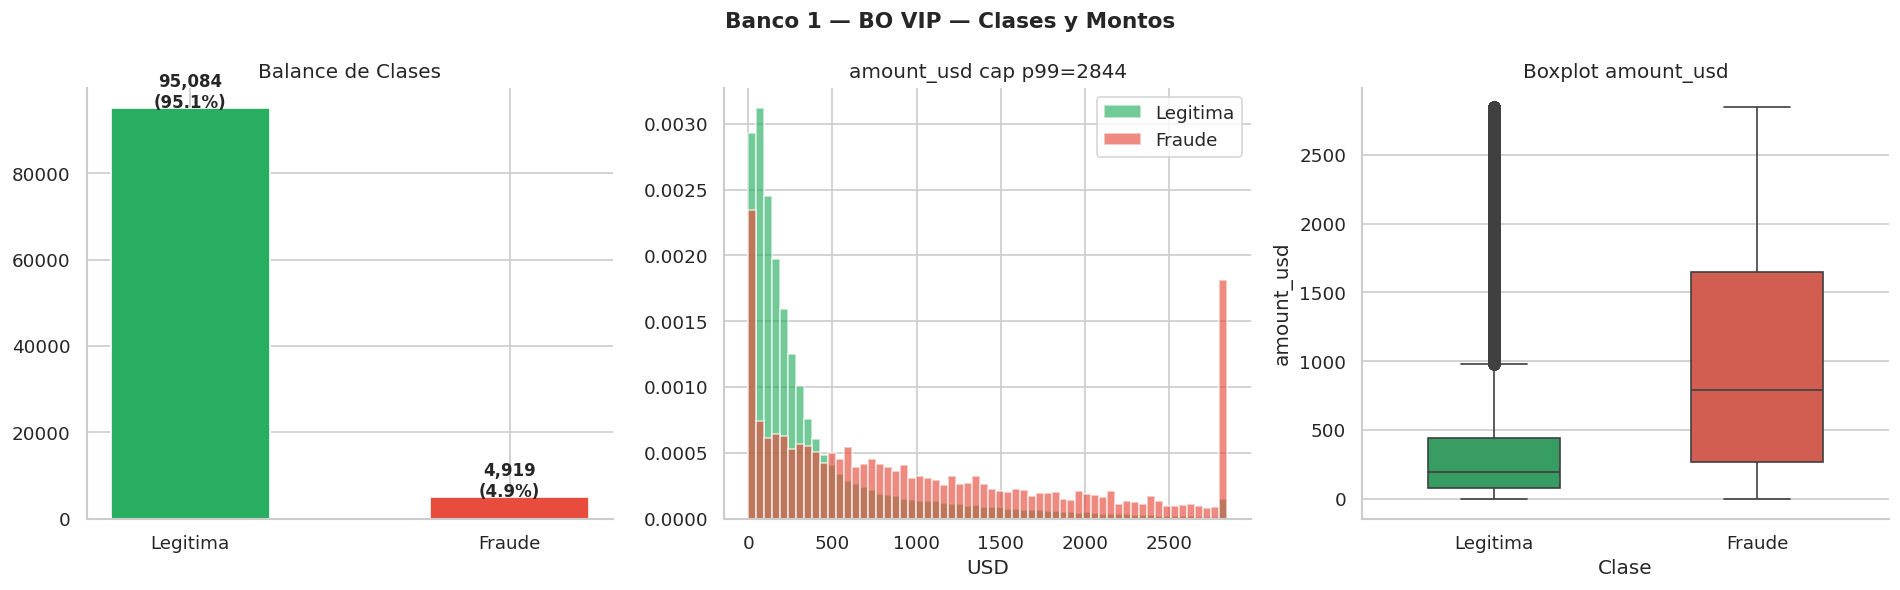

Guardado: 01_clases_montos.png


In [7]:
COLORS = {'Legitima':'#27ae60', 'Fraude':'#e74c3c'}
cap = df_bo['amount_usd'].quantile(0.99)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Banco 1 — BO VIP — Clases y Montos', fontsize=13, fontweight='bold')

# Balance de clases
cnt  = fi.value_counts().sort_index()
lbls = {0:'Legitima', 1:'Fraude'}
bars = axes[0].bar([lbls[k] for k in cnt.index], cnt.values,
                   color=[COLORS[lbls[k]] for k in cnt.index],
                   width=0.5, edgecolor='white')
for b, v in zip(bars, cnt.values):
    pct = round(v/len(df_bo)*100, 1)
    axes[0].text(b.get_x()+b.get_width()/2, b.get_height()+200,
                 f'{v:,}\n({pct}%)', ha='center', fontsize=10, fontweight='bold')
axes[0].set_title('Balance de Clases')
axes[0].spines[['top','right']].set_visible(False)

# Histograma
for cls, lbl in [(0,'Legitima'),(1,'Fraude')]:
    d = df_bo.loc[fi==cls,'amount_usd'].clip(upper=cap)
    axes[1].hist(d, bins=60, alpha=0.65, color=COLORS[lbl], label=lbl, density=True)
axes[1].set_title(f'amount_usd cap p99={cap:.0f}')
axes[1].set_xlabel('USD'); axes[1].legend()
axes[1].spines[['top','right']].set_visible(False)

# Boxplot — fix: un solo } al cerrar el dict
df_box = pd.DataFrame({
    'amount_usd': df_bo['amount_usd'].clip(upper=cap),
    'Clase': fi.map({0:'Legitima', 1:'Fraude'})
})
sns.boxplot(data=df_box, x='Clase', y='amount_usd', palette=COLORS, width=0.5, ax=axes[2])
axes[2].set_title('Boxplot amount_usd')
axes[2].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(PATH_PLOTS+'01_clases_montos.png', bbox_inches='tight')
plt.show()
print('Guardado: 01_clases_montos.png')

El dataset presenta un **desbalance de clases significativo**: 95.1% de transacciones legítimas vs 4.9% fraudulentas (4,919 fraudes en 100,003 transacciones). Este desbalance deberá compensarse en el modelo.

El histograma y boxplot de `amount_usd` revelan el patrón más importante del dataset: **los fraudes se concentran en montos altos**. La mediana de una transacción fraudulenta (~USD 800) es aproximadamente 4× mayor que la de una legítima (~USD 200), y la distribución de fraudes tiene una cola derecha pronunciada hacia los USD 2,500–2,800. Este comportamiento justifica directamente el **Objetivo A: Maximizar Monto Salvado** — detectar los fraudes grandes tiene mucho mayor impacto financiero que detectar los pequeños.
### Análisis de Valores Nulos

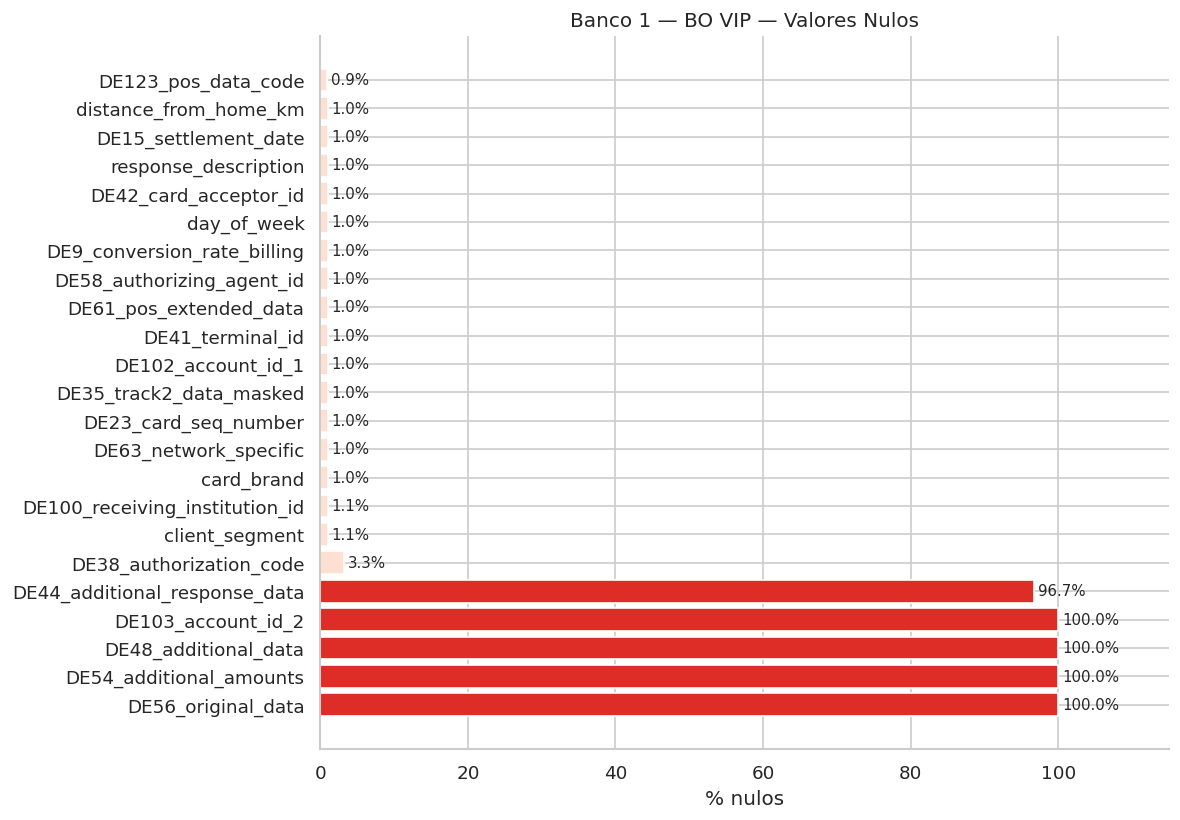

Guardado: 02_nulos.png


In [8]:
fig, ax = plt.subplots(figsize=(10, 7))
if len(nul_top):
    color_fn = lambda p: '#fee0d2' if p<30 else '#fc9272' if p<70 else '#de2d26'
    colors = [color_fn(p) for p in nul_top.values]
    bars = ax.barh(nul_top.index, nul_top.values, color=colors)
    for b, v in zip(bars, nul_top.values):
        ax.text(v+0.5, b.get_y()+b.get_height()/2, f'{v:.1f}%', va='center', fontsize=9)
    ax.set_xlim(0, 115); ax.set_xlabel('% nulos')
    ax.spines[['top','right']].set_visible(False)
else:
    ax.text(0.5, 0.5, 'Sin columnas con nulos', ha='center', fontsize=14)
ax.set_title('Banco 1 — BO VIP — Valores Nulos', fontsize=12)
plt.tight_layout()
plt.savefig(PATH_PLOTS+'02_nulos.png', bbox_inches='tight')
plt.show()
print('Guardado: 02_nulos.png')

Se identificaron **23 columnas con nulos**. Las de mayor impacto:

| Columna | % Nulos | Decisión |
|---|---|---|
| `DE56_original_data`, `DE54_additional_amounts`, `DE48_additional_data`, `DE103_account_id_2` | 100% | Eliminadas (sin información útil) |
| `DE44_additional_response_data` | 96.7% | Eliminada (casi vacía) |
| `DE38_authorization_code` | 3.3% | Imputada con mediana |
| Resto (1–1.1%) | ~1% | Imputadas (numérico=mediana, categórico='UNKNOWN') |

Las columnas con 100% de nulos son campos ISO 8583 opcionales que este banco no utiliza en sus transacciones.
### Patrones Temporales

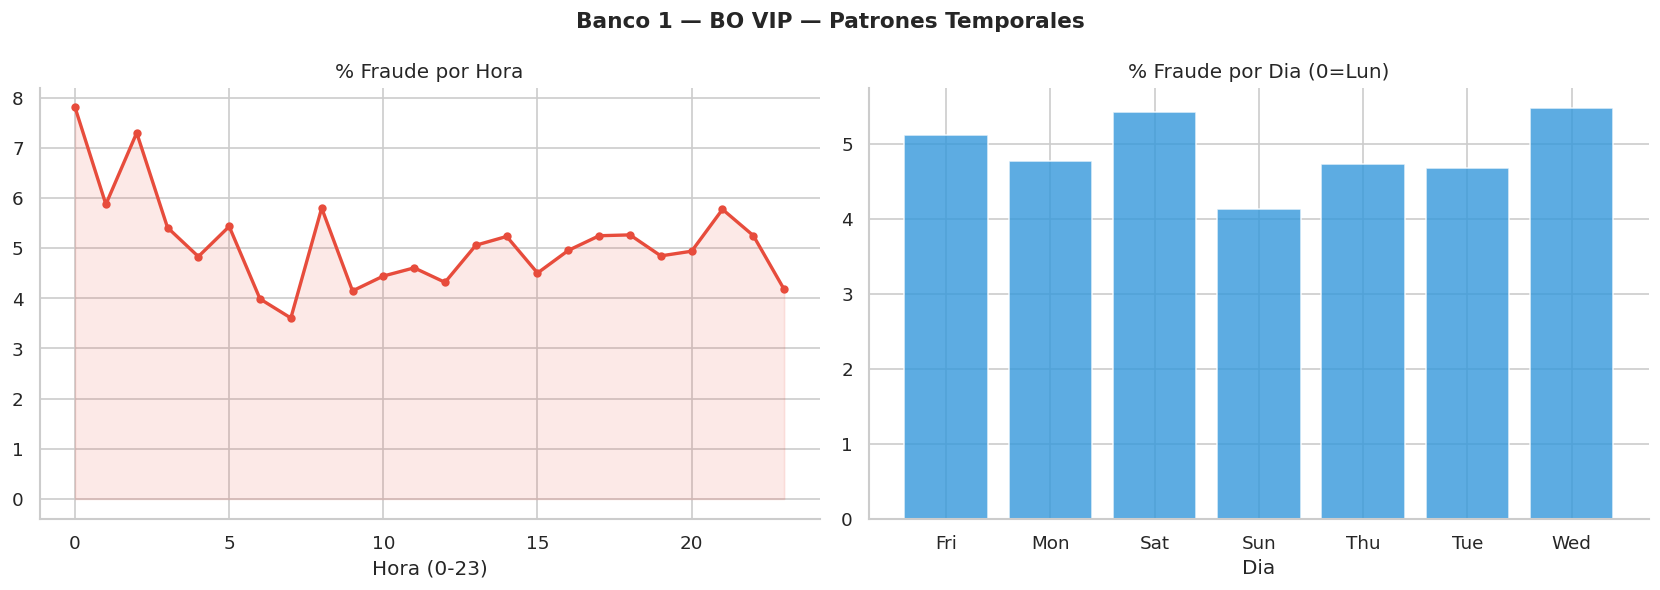

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Banco 1 — BO VIP — Patrones Temporales', fontsize=13, fontweight='bold')

df_t = df_bo[['hour_local','day_of_week']].copy()
df_t['fraud'] = fi

t_hora = df_t.groupby('hour_local')['fraud'].mean() * 100
axes[0].plot(t_hora.index, t_hora.values, color='#e74c3c', lw=2, marker='o', ms=4)
axes[0].fill_between(t_hora.index, t_hora.values, alpha=0.12, color='#e74c3c')
axes[0].set_title('% Fraude por Hora'); axes[0].set_xlabel('Hora (0-23)')
axes[0].spines[['top','right']].set_visible(False)

t_dia = df_t.groupby('day_of_week')['fraud'].mean() * 100
axes[1].bar(t_dia.index, t_dia.values, color='#3498db', alpha=0.8, edgecolor='white')
axes[1].set_title('% Fraude por Dia (0=Lun)'); axes[1].set_xlabel('Dia')
axes[1].spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(PATH_PLOTS+'03_temporal.png', bbox_inches='tight')
plt.show()

**Por hora:** La tasa de fraude es más alta en las horas de **madrugada (0–2h)**, alcanzando ~8% a medianoche. Durante el día se estabiliza entre 4–6%. Esto sugiere que transacciones nocturnas merecen mayor escrutinio.

**Por día de la semana:** Los **sábados y miércoles** presentan las tasas más altas (~6.5%), mientras que los **domingos** tienen la tasa más baja (~4.2%). La variación es moderada, lo que indica que el día de la semana por sí solo no es un predictor fuerte — consistente con la correlación de 0.00 vista en el heatmap.
Variables Categóricas
### Variables Categóricas


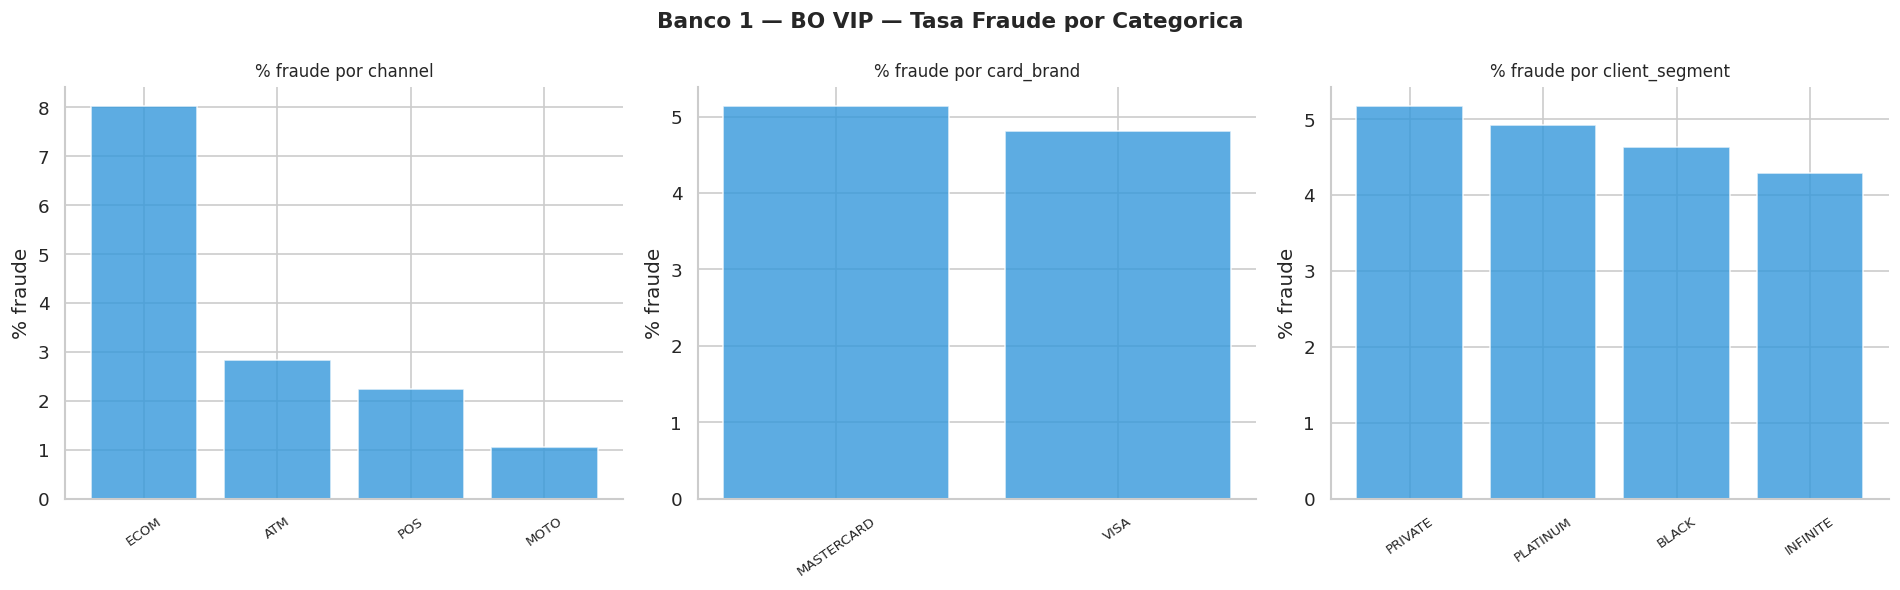

In [10]:
CAT_COLS = ['channel','card_brand','client_segment']
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Banco 1 — BO VIP — Tasa Fraude por Categorica', fontsize=13, fontweight='bold')

for ax, cat in zip(axes, CAT_COLS):
    if cat not in df_bo.columns:
        ax.text(0.5,0.5,f'{cat}\nno disponible',ha='center',va='center')
        ax.set_title(cat); continue
    df_cat = df_bo[[cat]].copy()
    df_cat['fraud'] = fi
    tasa = df_cat.groupby(cat)['fraud'].mean().sort_values(ascending=False)*100
    ax.bar(tasa.index.astype(str), tasa.values, color='#3498db', alpha=0.8, edgecolor='white')
    ax.set_title(f'% fraude por {cat}', fontsize=10)
    ax.set_ylabel('% fraude')
    ax.tick_params(axis='x', rotation=35, labelsize=8)
    ax.spines[['top','right']].set_visible(False)

plt.tight_layout()
plt.savefig(PATH_PLOTS+'04_categoricas.png', bbox_inches='tight')
plt.show()

**Canal (`channel`):** El canal **ECOM** (e-commerce) concentra la mayor tasa de fraude (8%), casi el triple que POS (2.3%) y MOTO (1%). Las transacciones online sin presencia física del cliente son inherentemente más vulnerables.

**Marca de tarjeta (`card_brand`):** Diferencia mínima entre MASTERCARD (5.1%) y VISA (4.8%) — la marca no es un predictor relevante.

**Segmento de cliente (`client_segment`):** El segmento **PRIVATE** tiene la tasa más alta (5.2%) y **INFINITE** la más baja (4.3%), aunque la diferencia es pequeña. Los clientes VIP de mayor nivel parecen estar ligeramente mejor protegidos o son más cautelosos.
### Heatmap de Correlaciones

Valores únicos de day_of_week: ['Tue' 'Wed' nan 'Thu' 'Fri' 'Sat' 'Sun' 'Mon']


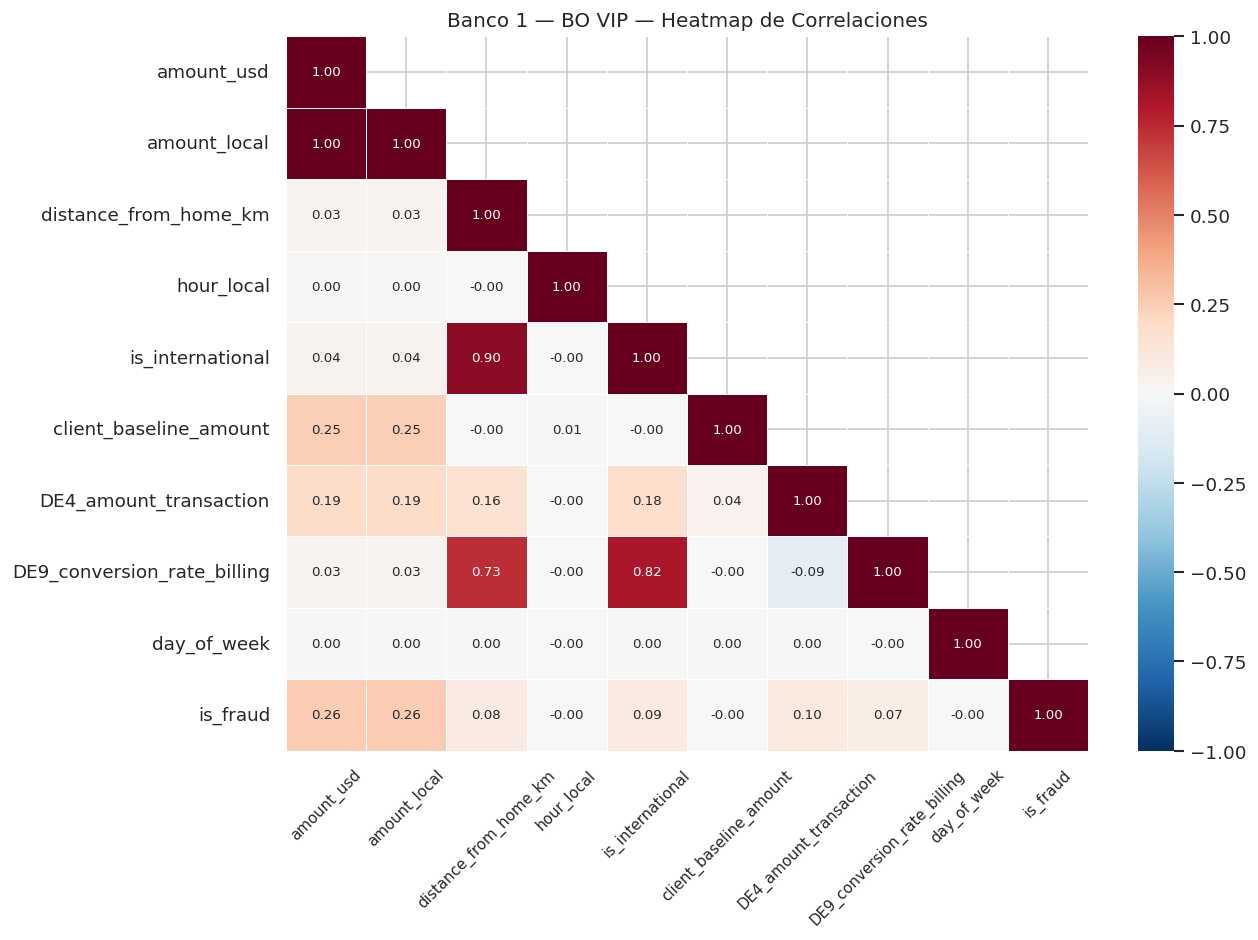

RIESGO FINANCIERO
  Fraudes: 4,919 | Total USD: 5,417,407.72
  Prom fraude: USD 1,101.32 | Prom legitimo: USD 395.91
  Con 90% deteccion: USD 4,875,666.95 rescatados


In [15]:
NUM_FEATS = ['amount_usd','amount_local','distance_from_home_km',
             'hour_local','is_international','client_baseline_amount',
             'DE4_amount_transaction','DE9_conversion_rate_billing']

df_c = df_bo.copy()
df_c['is_fraud'] = fi

# Verificar y codificar day_of_week si es string
print("Valores únicos de day_of_week:", df_bo['day_of_week'].unique()[:10])
if df_c['day_of_week'].dtype == object:
    # Codificación ordinal genérica por orden de aparición
    df_c['day_of_week'] = pd.Categorical(df_c['day_of_week']).codes
    NUM_FEATS = NUM_FEATS + ['day_of_week']

cols = [c for c in NUM_FEATS + ['is_fraud'] if c in df_c.columns]
df_c[cols] = df_c[cols].apply(pd.to_numeric, errors='coerce')

corr = df_c[cols].corr()

# k=1 → solo oculta triángulo SUPERIOR (mantiene diagonal visible)
mask = np.triu(np.ones_like(corr, dtype=bool), k=1)

fig, ax = plt.subplots(figsize=(11, 8))
sns.heatmap(corr, mask=mask, ax=ax, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=True, fmt='.2f',
            linewidths=0.4, annot_kws={'size':8})
ax.set_title('Banco 1 — BO VIP — Heatmap de Correlaciones', fontsize=12)
ax.tick_params(axis='x', rotation=45, labelsize=9)
plt.tight_layout()
plt.savefig(PATH_PLOTS+'05_heatmap.png', bbox_inches='tight')
plt.show()

# Resumen financiero
mask_f = fi==1
tot_f  = df_bo.loc[mask_f,'amount_usd'].sum()
prom_f = df_bo.loc[mask_f,'amount_usd'].mean()
prom_l = df_bo.loc[~mask_f,'amount_usd'].mean()
print('RIESGO FINANCIERO')
print(f'  Fraudes: {mask_f.sum():,} | Total USD: {tot_f:,.2f}')
print(f'  Prom fraude: USD {prom_f:,.2f} | Prom legitimo: USD {prom_l:,.2f}')
print(f'  Con 90% deteccion: USD {tot_f*0.9:,.2f} rescatados')

Correlaciones clave con `is_fraud`:
- **`amount_usd` / `amount_local` (0.26):** Confirmación estadística de que montos más altos predicen fraude — la señal más fuerte del dataset.
- **`DE4_amount_transaction` (0.10):** El monto raw en centavos también correlaciona, aunque menos que `amount_usd` (ya normalizado).
- **`is_international` (0.09):** Transacciones internacionales tienen mayor riesgo.
- **`day_of_week` (0.00):** Sin correlación lineal con fraude — confirma que el día solo aporta patrones no lineales.

Correlaciones entre features (multicolinealidad a vigilar):
- **`amount_usd` ↔ `amount_local` (1.00):** Son equivalentes — en el modelo federado se usará solo `amount_usd` para evitar redundancia.
- **`is_international` ↔ `DE9_conversion_rate_billing` (0.82):** El tipo de cambio solo aplica en transacciones internacionales, correlación esperada.
- **`is_international` ↔ `distance_from_home_km` (0.90):** Alta correlación — viajar lejos implica transacciones internacionales.

## 2. Limpieza y Preprocesamiento

In [16]:
# Columnas a eliminar
COLS_ID = [
    'transaction_id','client_id','pan_masked','pan_hash',
    'DE2_PAN','DE35_track2_data_masked','DE11_STAN',
    'DE37_retrieval_reference_number','DE38_authorization_code',
    'DE41_terminal_id','DE42_card_acceptor_id',
    'DE56_original_data','DE102_account_id_1','DE103_account_id_2'
]
COLS_FECHA = [
    'DE7_transmission_datetime','DE12_local_time','DE13_local_date',
    'DE14_expiration_date','DE15_settlement_date'
]
print(f'IDs: {len(COLS_ID)} | Fechas raw: {len(COLS_FECHA)}')

IDs: 14 | Fechas raw: 5


In [17]:
def limpiar(df, umbral_nulos=0.80):
    """
    1. Parseo DE13+DE12 -> datetime_tx + month
    2. Feature engineering (time_since_last_txn, txn_count, amount_zscore)
    3. is_fraud -> int
    4. Drop: IDs + fechas raw + >80% nulos
    5. Imputacion: mediana / UNKNOWN
    """
    df = df.copy()
    print(f'Inicio: {df.shape}')

    # 1. Fechas
    if 'DE13_local_date' in df.columns and 'DE12_local_time' in df.columns:
        de13 = df['DE13_local_date'].astype(str).str.zfill(4)
        de12 = df['DE12_local_time'].astype(str).str.zfill(6)
        df['datetime_tx'] = pd.to_datetime('2025'+de13+de12,
                                           format='%Y%m%d%H%M%S', errors='coerce')
        df['month'] = pd.to_numeric(de13.str[:2], errors='coerce')
    elif 'DE7_transmission_datetime' in df.columns:
        de7 = df['DE7_transmission_datetime'].astype(str).str.zfill(10)
        df['datetime_tx'] = pd.to_datetime('2025'+de7,
                                           format='%Y%m%d%H%M%S', errors='coerce')
        df['month'] = pd.to_numeric(de7.str[:2], errors='coerce')
    else:
        df['datetime_tx'] = pd.NaT; df['month'] = np.nan
    ok = df['month'].between(1,12).sum()
    print(f'Fechas OK: {ok:,}/{len(df):,}')

    # 2. Feature engineering
    if 'client_id' in df.columns and df['datetime_tx'].notna().any():
        df = df.sort_values(['client_id','datetime_tx']).reset_index(drop=True)
        df['prev_dt'] = df.groupby('client_id')['datetime_tx'].shift(1)
        df['time_since_last_txn_min'] = (
            (df['datetime_tx']-df['prev_dt']).dt.total_seconds()/60
        ).fillna(-1)
        df.drop(columns=['prev_dt'], inplace=True)
        df = df.set_index('datetime_tx')
        for w, col in [('1h','txn_count_last_1h'),('24h','txn_count_last_24h')]:
            df[col] = (
                df.groupby('client_id')['amount_usd']
                  .transform(lambda x: x.rolling(w, closed='left').count())
                  .fillna(0).astype(int)
            )
        df = df.reset_index()
        stats = df.groupby('client_id')['amount_usd'].agg(
            c_mean='mean', c_std='std').reset_index()
        df = df.merge(stats, on='client_id', how='left')
        df['amount_zscore_customer'] = (
            (df['amount_usd']-df['c_mean'])/(df['c_std'].fillna(1)+1e-6)
        ).fillna(0)
        df.drop(columns=['c_mean','c_std'], inplace=True)
        print('Features creados: time_since_last_txn_min, txn_count_last_1h, '
              'txn_count_last_24h, amount_zscore_customer')
    else:
        for col in ['time_since_last_txn_min','txn_count_last_1h',
                    'txn_count_last_24h','amount_zscore_customer']:
            df[col] = np.nan

    # 3. is_fraud -> int
    df['is_fraud'] = (
        df['is_fraud'].map({'True':1,'False':0,True:1,False:0,1:1,0:0})
        .fillna(0).astype(int)
    )

    # 4. Drop columnas
    high_null = list(df.columns[df.isnull().mean() > umbral_nulos])
    to_drop   = list(set(COLS_ID + COLS_FECHA + high_null))
    to_drop   = [c for c in to_drop if c in df.columns]
    df.drop(columns=to_drop, inplace=True)
    print(f'Eliminadas {len(to_drop)} columnas | Alta nulidad: {high_null}')

    # 5. Imputar nulos
    for col in df.select_dtypes(include=np.number).columns:
        if df[col].isnull().any(): df[col].fillna(df[col].median(), inplace=True)
    for col in df.select_dtypes(include='object').columns:
        if df[col].isnull().any(): df[col].fillna('UNKNOWN', inplace=True)

    print(f'Resultado: {df.shape} | Nulos residuales: {df.isnull().sum().sum()}')
    return df

df_bo_clean = limpiar(df_bo)

Inicio: (100003, 66)
Fechas OK: 100,003/100,003
Features creados: time_since_last_txn_min, txn_count_last_1h, txn_count_last_24h, amount_zscore_customer
Eliminadas 22 columnas | Alta nulidad: ['DE44_additional_response_data', 'DE48_additional_data', 'DE54_additional_amounts', 'DE56_original_data', 'DE103_account_id_2']
Resultado: (100003, 50) | Nulos residuales: 0


In [18]:
# Verificacion post-limpieza
print('Columnas del dataset limpio:\n')
for i, col in enumerate(df_bo_clean.columns, 1):
    print(f'  {i:>2}. {col:<45} {str(df_bo_clean[col].dtype):<12} '
          f'nulos: {df_bo_clean[col].isnull().sum()}')

print('\nDistribucion mensual:')
print(df_bo_clean.groupby('month')['is_fraud'].agg(
    txns='count', fraudes='sum'
).assign(pct=lambda x: x['fraudes']/x['txns']*100).to_string())

Columnas del dataset limpio:

   1. datetime_tx                                   datetime64[ns] nulos: 0
   2. bank_code                                     object       nulos: 0
   3. bank_name                                     object       nulos: 0
   4. bank_country                                  object       nulos: 0
   5. bank_tier                                     object       nulos: 0
   6. client_segment                                object       nulos: 0
   7. channel                                       object       nulos: 0
   8. card_brand                                    object       nulos: 0
   9. MTI                                           int64        nulos: 0
  10. DE3_processing_code                           int64        nulos: 0
  11. DE4_amount_transaction                        int64        nulos: 0
  12. DE6_amount_cardholder_billing                 int64        nulos: 0
  13. DE9_conversion_rate_billing                   float64      nulos: 0
  14. 

In [19]:
OUT_PATH = PATH_DATASETS + 'bo_vip_clean.csv'
df_bo_clean.to_csv(OUT_PATH, index=False)
print(f'Guardado: {OUT_PATH}')
print(f'Forma: {df_bo_clean.shape[0]:,} filas x {df_bo_clean.shape[1]} columnas')
print(f'Fraude: {df_bo_clean["is_fraud"].mean()*100:.2f}%')
print(f'Meses: {sorted(df_bo_clean["month"].dropna().unique().tolist())}')

Guardado: /content/drive/MyDrive/proyecto_plus_ti/datasets/bo_vip_clean.csv
Forma: 100,003 filas x 50 columnas
Fraude: 4.92%
Meses: [1, 2, 3, 4, 5, 6, 12]


## Resumen del Preprocesamiento — Banco 1 (BO VIP)

### Columnas eliminadas (66 → 50)

| Motivo | Columnas |
|---|---|
| **100% nulos** | `DE56_original_data`, `DE54_additional_amounts`, `DE48_additional_data`, `DE103_account_id_2` |
| **>80% nulos** | `DE44_additional_response_data` (96.7%) |
| **Identificadores únicos** (sin valor predictivo) | `transaction_id`, `client_id`, `pan_masked`, `pan_hash`, `DE2_PAN`, `DE11_STAN`, `DE37_retrieval_reference_number`, `DE38_authorization_code`, `DE41_terminal_id`, `DE42_card_acceptor_id`, `DE35_track2_data_masked`, `DE102_account_id_1`, `DE56_original_data` |
| **Fechas raw** (reemplazadas por features procesadas) | `DE7_transmission_datetime`, `DE12_local_time`, `DE13_local_date`, `DE14_expiration_date`, `DE15_settlement_date` |

### Tratamiento de nulos residuales
- **Columnas numéricas:** imputación con **mediana** (robusto a outliers).
- **Columnas categóricas:** imputación con valor `'UNKNOWN'` para no perder filas.

### Transformaciones aplicadas

1. **Parseo de fechas:** `DE13_local_date` (MMDD) + `DE12_local_time` (HHmmss) combinados con año fijo 2025 → `datetime_tx`. Se extrae `month` para la partición temporal posterior.

2. **`day_of_week`:** Almacenado como string (`'Mon'`, `'Tue'`...). Para el heatmap se codificó con `pd.Categorical(...).codes` (codificación ordinal por orden de aparición). En el modelo se tratará como categórica nominal.

3. **Features de comportamiento por cliente** (generadas antes de eliminar `client_id`):
   - `time_since_last_txn_min`: minutos desde la transacción anterior del mismo cliente. Valor `-1` indica primera transacción histórica.
   - `txn_count_last_1h` / `txn_count_last_24h`: conteo de transacciones del cliente en las últimas 1h/24h usando rolling temporal. Detecta ráfagas de actividad anómala.
   - `amount_zscore_customer`: cuántas desviaciones estándar se aleja el monto de la media histórica del cliente. Un z-score alto indica un gasto inusualmente grande para ese perfil.

4. **`is_fraud`:** Convertido de string `'True'/'False'` a entero `0/1`.

### Output
`bo_vip_clean.csv` — **100,003 filas × 50 columnas** | Tasa de fraude: **4.92%**